In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import RESULTS_DIR

%matplotlib inline

In [2]:
df = pd.read_csv(RESULTS_DIR / "summary.csv")
df.head(10)

,ticker,model,task,train_mae,train_rmse,test_mae,test_rmse,test_mape,test_accuracy,test_f1,test_roc_auc
0,AAPL,Ridge,regression,1.151110,1.850506,2.829802,4.065635,1.274633,NaN,NaN,NaN
1,AAPL,Logistic,classification,NaN,NaN,NaN,NaN,NaN,0.503534,0.464762,0.497861
2,AAPL,RandomForest,regression,NaN,NaN,2.960104,4.390148,1.329323,NaN,NaN,NaN
3,AAPL,RandomForest,classification,NaN,NaN,NaN,NaN,NaN,0.443463,0.136986,0.546751
4,AAPL,XGBoost,regression,NaN,NaN,3.416860,4.512918,1.519167,NaN,NaN,NaN
5,AAPL,XGBoost,classification,NaN,NaN,NaN,NaN,NaN,0.461131,0.182306,0.522211
6,MSFT,Ridge,regression,2.064362,3.304780,4.976045,7.013124,1.161945,NaN,NaN,NaN
7,MSFT,Logistic,classification,NaN,NaN,NaN,NaN,NaN,0.510601,0.536013,0.495533
8,MSFT,RandomForest,regression,NaN,NaN,4.719535,6.824293,1.103472,NaN,NaN,NaN
9,MSFT,RandomForest,classification,NaN,NaN,NaN,NaN,NaN,0.487633,0.561934,0.472710


In [3]:
reg = df[df["task"] == "regression"]
reg_pivot = reg.pivot(index="ticker", columns="model", values="test_mae")
reg_pivot.round(3)

model,RandomForest,Ridge,XGBoost
ticker,,,
AAPL,2.960,2.830,3.417
AMZN,6.028,3.058,4.438
JNJ,1.583,1.421,2.442
JPM,2.628,2.776,3.175
KO,1.010,0.524,1.160
MSFT,4.720,4.976,5.135
NVDA,3.198,3.082,3.320
TSLA,10.305,8.474,10.198


In [4]:
reg.groupby("model")["test_mae"].mean().sort_values().round(3)

model
Ridge           3.393
RandomForest    4.054
XGBoost         4.161
Name: test_mae, dtype: float64

In [5]:
clf = df[df["task"] == "classification"]
clf_pivot = clf.pivot(index="ticker", columns="model", values="test_accuracy")
clf_pivot.round(4)

model,Logistic,RandomForest,XGBoost
ticker,,,
AAPL,0.5035,0.4435,0.4611
AMZN,0.4823,0.4664,0.4594
JNJ,0.4629,0.5106,0.5477
JPM,0.4735,0.4929,0.4611
KO,0.5088,0.5035,0.5018
MSFT,0.5106,0.4876,0.4965
NVDA,0.4912,0.5389,0.5389
TSLA,0.5141,0.5018,0.5018


In [6]:
clf.groupby("model")["test_accuracy"].mean().sort_values(ascending=False).round(4)

model
XGBoost         0.4960
Logistic        0.4934
RandomForest    0.4932
Name: test_accuracy, dtype: float64

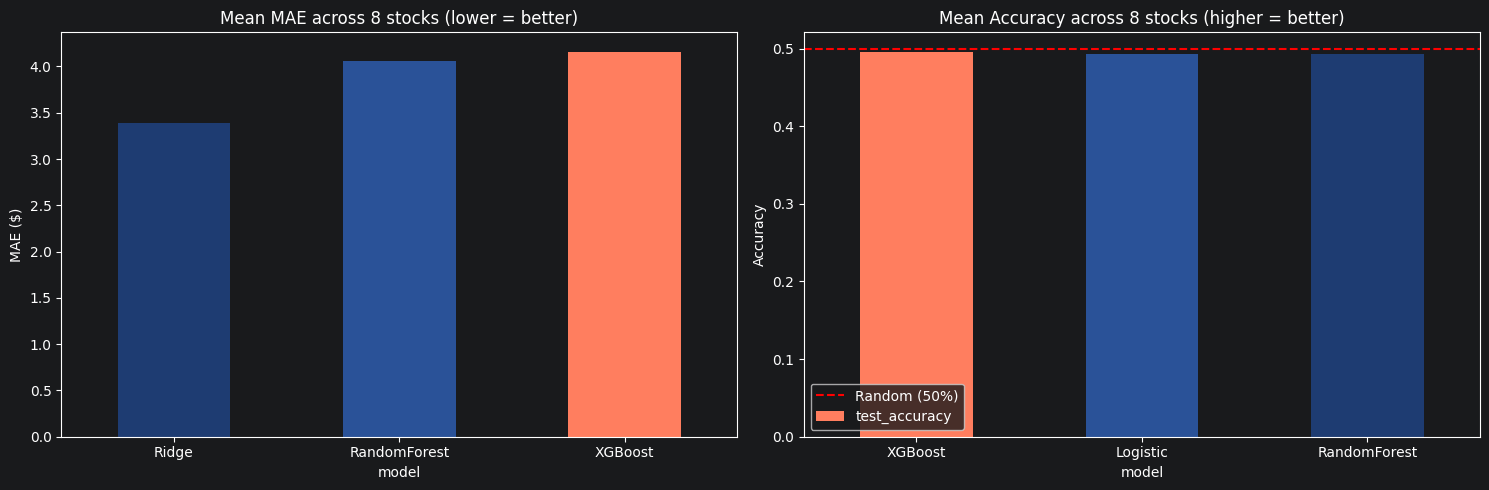

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

reg.groupby("model")["test_mae"].mean().sort_values().plot(
    kind="bar", ax=axes[0], color=["#1e3c72", "#2a5298", "#ff7e5f"]
)
axes[0].set_title("Mean MAE across 8 stocks (lower = better)")
axes[0].set_ylabel("MAE ($)")
axes[0].tick_params(axis="x", rotation=0)

clf.groupby("model")["test_accuracy"].mean().sort_values(ascending=False).plot(
    kind="bar", ax=axes[1], color=["#ff7e5f", "#2a5298", "#1e3c72"]
)
axes[1].set_title("Mean Accuracy across 8 stocks (higher = better)")
axes[1].set_ylabel("Accuracy")
axes[1].axhline(0.5, color="red", linestyle="--", label="Random (50%)")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

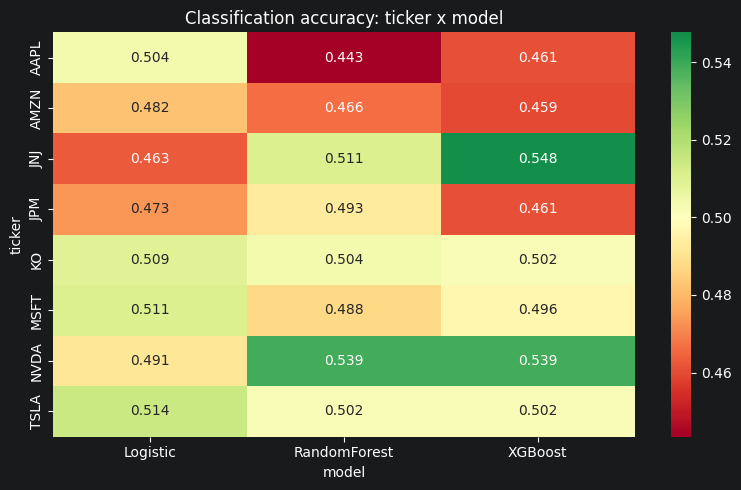

In [8]:
plt.figure(figsize=(8, 5))
sns.heatmap(clf_pivot, annot=True, fmt=".3f", cmap="RdYlGn", center=0.5)
plt.title("Classification accuracy: ticker x model")
plt.tight_layout()
plt.show()

In [9]:
best_clf = clf.loc[clf.groupby("ticker")["test_accuracy"].idxmax()]
best_clf[["ticker", "model", "test_accuracy", "test_f1", "test_roc_auc"]]

,ticker,model,test_accuracy,test_f1,test_roc_auc
1,AAPL,Logistic,0.503534,0.464762,0.497861
19,AMZN,Logistic,0.482332,0.069841,0.531140
47,JNJ,XGBoost,0.547703,0.443478,0.546743
33,JPM,RandomForest,0.492933,0.360802,0.522574
37,KO,Logistic,0.508834,0.593567,0.513282
7,MSFT,Logistic,0.510601,0.536013,0.495533
15,NVDA,RandomForest,0.538869,0.700344,0.515985
25,TSLA,Logistic,0.514134,0.453280,0.526539


In [10]:
best_reg = reg.loc[reg.groupby("ticker")["test_mae"].idxmin()]
best_reg[["ticker", "model", "test_mae", "test_rmse", "test_mape"]]

,ticker,model,test_mae,test_rmse,test_mape
0,AAPL,Ridge,2.829802,4.065635,1.274633
18,AMZN,Ridge,3.058373,4.196173,1.486434
42,JNJ,Ridge,1.420644,1.944148,0.837413
32,JPM,RandomForest,2.627616,3.813670,1.056142
36,KO,Ridge,0.523736,0.695647,0.782636
8,MSFT,RandomForest,4.719535,6.824293,1.103472
12,NVDA,Ridge,3.081825,4.146110,2.304320
24,TSLA,Ridge,8.474055,11.493965,2.780258
